In [61]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

import re
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler

from scipy.sparse import csr_matrix, hstack

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

import spacy

import scipy.stats as ss
from scipy.stats import pointbiserialr

import joblib

# 1. Dataset and Data Ingestion 

In [3]:
reviews = pd.read_csv('BA_AirlineReviews.csv')

# Rename columns according to convention 
def name_pythonizer(column_name):
    # Insert underscore before capital letters that are preceded by a lowercase letter or digit
    column_name = re.sub(r'(?<=[a-z0-9])([A-Z])', r'_\1', column_name)
    
    # Convert to lowercase
    column_name = column_name.lower()
    
    # Replace dots and spaces with underscores
    column_name = column_name.replace('.', '_').replace(' ', '_')
    
    return column_name
    
reviews.columns = reviews.columns.map(name_pythonizer)



In [4]:
# Map the values of overall_rating to sentiments 
def map_sentiment_5(x):
    if x <= 2:
        return "very_negative"
    elif x <= 4:
        return "negative"
    elif x <= 6:
        return "neutral"
    elif x <= 8:
        return "positive"
    else:
        return "very_positive"

reviews['sentiment_5'] = reviews['overall_rating'].apply(map_sentiment_5)

In [5]:
# Remove all unnecessary features (reasoning omitted in this file)
reviews = reviews.drop(columns=['verified_review', 'review_header', 'aircraft', 'unnamed:_0', 'route', 'name', 'type_of_traveller', 'seat_type'])

In [17]:
# Special treatment of temporal features 

#Ensure date_flown and datetime are in datetime format 
reviews['date_flown'] = pd.to_datetime(reviews['date_flown'], errors='coerce')
reviews['datetime'] = pd.to_datetime(reviews['datetime'], errors='coerce') 

# Create feature flight_year and flight_month from date_flown
reviews['flight_year'] = reviews['date_flown'].dt.year
reviews['flight_month'] = reviews['date_flown'].dt.month

# Create imputer (median is chosen as it is robust for ratings)
imputer = SimpleImputer(strategy='median')

# Fit and transform
reviews[['flight_year', 'flight_month']] = imputer.fit_transform(reviews[['flight_year', 'flight_month']])

# Creation of flight_season

'''
Seasons are defined as follows in the next line:
Winter: December, January, February
Spring: March, April, May
Summer: June, July, August
Autumn: September, October, November
At this point, potential differences between the meteorological and tourist-perspective seasonality will be neglected
'''
reviews['flight_season'] = reviews['flight_month'] % 12 // 3

# Cyclical encoding for flight_month
def add_cyclical_month_features(df):
    df["month_sin"] = np.sin(2 * np.pi * df["flight_month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["flight_month"] / 12)
    return df

reviews = add_cyclical_month_features(reviews)

C:\Users\user\AppData\Local\Temp\ipykernel_57536\634296969.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  reviews['date_flown'] = pd.to_datetime(reviews['date_flown'], errors='coerce')


In [25]:
'''
Remove all observations where the difference between overall_rating and 
the mean of the other rating features is more than 25% 
(this removes approximately 9% of the observations)
''' 
# Create a list of all rating columns 
rating_cols = [
    'seat_comfort',
    'cabin_staff_service',
    'ground_service',
    'value_for_money',
    'food&beverages',
    'inflight_entertainment',
    'wifi&connectivity'
]

# Compute row-wise mean of the listed features and store 
calculated_mean = reviews[rating_cols].mean(axis=1) 
reviews['rating_mean'] = calculated_mean

# Create features overall_norm and mean_norm for this purpose
reviews['overall_norm'] = (reviews['overall_rating'] - 1) / 9
reviews['mean_norm'] = (reviews['rating_mean'] - 1) / 4

# Calculate the absolute difference 
reviews['abs_difference'] = abs(
    reviews['overall_norm']
    - reviews['mean_norm'])

# Remove all observations where abs_difference > 0.25, i.e. keep only the rest
# Note: clean_df will be used for training only. Testing is to be conducted on reviews 
clean_df = reviews[reviews['abs_difference'] <= 0.25]

In [27]:
# Definition of feature groups (to be used later)

text_column = "review_body"

rating_columns = [
    'seat_comfort',
    'cabin_staff_service',
    'ground_service',
    'value_for_money',
    'food&beverages',
    'inflight_entertainment',
    'wifi&connectivity',
    'recommended'
]

categorical_time_lr = ['flight_season']                   # For Logistic

numeric_time_lr = ['flight_year', 'month_sin', 'month_cos']



# 2. Text Preprocessing and 3. Negation and Multipolarity Handling

In [30]:
# Load English model
nlp = spacy.load("en_core_web_sm")

class TextPreprocessor(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        processed = []
        
        for text in X:
            if pd.isna(text):
                processed.append("")
                continue
            
            doc = nlp(text.lower())
            tokens = []
            negated_tokens = set()
            
            # Detect negations using dependency parsing
            for token in doc:
                if token.dep_ == "neg":
                    head = token.head
                    negated_tokens.add(head.i)
            
            for token in doc:
                
                # Skip stopwords and punctuation
                if token.is_stop or token.is_punct:
                    continue
                
                lemma = token.lemma_
                
                # Apply negation marking
                if token.i in negated_tokens:
                    lemma = "NEG_" + lemma
                
                # Keep only content words
                if token.pos_ in ["NOUN", "VERB", "ADJ", "ADV"]:
                    tokens.append(lemma)
            
            # Contrast marker detection
            if any(token.text in ["but", "however", "although"] for token in doc):
                tokens.append("CONTRAST")
            
            processed.append(" ".join(tokens))
        
        return processed

        
    def get_feature_names_out(self, input_features=None):
        return input_features


In [32]:
# Preprocessor 

preprocessor_lr = ColumnTransformer(
    transformers=[
        (
            'text',
            Pipeline([
                ('neg_multi', TextPreprocessor()),
                ('tfidf', TfidfVectorizer())
            ]),
            text_column
        ),
        (
            'ratings',
            OneHotEncoder(handle_unknown='ignore'),
            rating_columns
        ),
        (
            'season',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_time_lr
        ),
        (
            'numeric_time',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', MinMaxScaler())
            ]),
            numeric_time_lr
        )
    ]
)

# 4. Feature extraction and Encoding

In [35]:
# Select feature columns 
feature_columns_lr = (
    [text_column] +
    rating_columns +
    categorical_time_lr +
    numeric_time_lr
)

In [39]:
#Encoding of target variable for training (y_5) and testing (y_51)

# Create Label Encoder 
le_5 = LabelEncoder()

# Target variable for training
y_51 = le_5.fit_transform(clean_df['sentiment_5'])

# Target variable for testing
y_5 = le_5.fit_transform(reviews['sentiment_5'])

In [43]:
# Perform train-test split for training and testing 
# Note: Each variable, referrig to the clean dataset (clean_df) will end with 1
 
# Split for training 
X_lr_1 = clean_df[feature_columns_lr]

X_train_lr_51, X_test_lr_51, y_train_51, y_test_51 = train_test_split(
    X_lr_1, y_51, test_size=0.2, random_state=42, stratify=y_51)

# Split for testing 
X_lr = reviews[feature_columns_lr]

X_train_lr_5, X_test_lr_5, y_train_5, y_test_5 = train_test_split(
    X_lr, y_5, test_size=0.2, random_state=41, stratify=y_5)

'''
Previous version:
X_lr_2 = clean_df[feature_columns_lr]

X_train_lr_51, X_test_lr_51, y_train_51, y_test_51 = train_test_split(
    X_lr_2, y_51, test_size=0.2, random_state=42, stratify=y_51)
'''


'\nPrevious version:\nX_lr_2 = clean_df[feature_columns_lr]\n\nX_train_lr_51, X_test_lr_51, y_train_51, y_test_51 = train_test_split(\n    X_lr_2, y_51, test_size=0.2, random_state=42, stratify=y_51)\n'

# 5. Model training and sentiment classification

In [46]:
lr_classifier = Pipeline([
    ('preprocessor', preprocessor_lr),
('classifier', LogisticRegression(max_iter=5000))
])

lr_classifier.fit(X_train_lr_51, y_train_51)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('neg_multi',
                                                                   TextPreprocessor()),
                                                                  ('tfidf',
                                                                   TfidfVectorizer())]),
                                                  'review_body'),
                                                 ('ratings',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['seat_comfort',
                                                   'cabin_staff_service',
                                                   'ground_service',
                                                   'value_for_money',
                                                   'food&beverages',
                                                   'inflight_entertainment',
                                                   'wifi&connectivity',
                                                   'recommended']),
                                                 ('season',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['flight_season']),
                                                 ('numeric_time',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['flight_year', 'month_sin',
                                                   'month_cos'])])),
                ('classifier', LogisticRegression(max_iter=5000))])

# 6. Output, Reporting and Evaluation

In [51]:
# Use the model to predict values 
y_pred_lr = lr_classifier.predict(X_test_lr_5)

In [56]:
# Metrics overview 
print(classification_report(y_test_5, y_pred_lr))

              precision    recall  f1-score   support

           0       0.62      0.73      0.67       132
           1       0.70      0.61      0.65        85
           2       0.80      0.81      0.80       137
           3       0.88      0.83      0.85       258
           4       0.86      0.88      0.87       129

    accuracy                           0.79       741
   macro avg       0.77      0.77      0.77       741
weighted avg       0.79      0.79      0.79       741



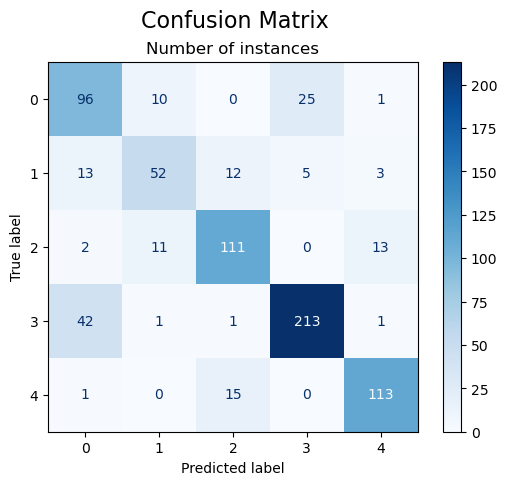

In [108]:
# Confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test_5,
    y_pred_lr,
    cmap='Blues'
)

plt.suptitle("Confusion Matrix", x=0.46, y=0.99, fontsize=16)
plt.title("Number of instances", fontsize=12)
plt.show()

Train Accuracy: 0.887
Test Accuracy: 0.789


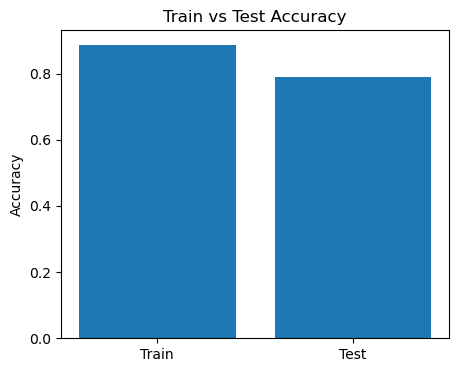

In [72]:
train_acc_lr = accuracy_score(y_train_51, lr_classifier.predict(X_train_lr_51))
test_acc_lr = accuracy_score(y_test_5, y_pred_lr)

print(f"Train Accuracy: {train_acc_lr:.3f}")
print(f"Test Accuracy: {test_acc_lr:.3f}")

plt.figure(figsize=(5,4))

plt.bar(
    ['Train', 'Test'],
    [train_acc_lr, test_acc_lr]
)

plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')

plt.show()

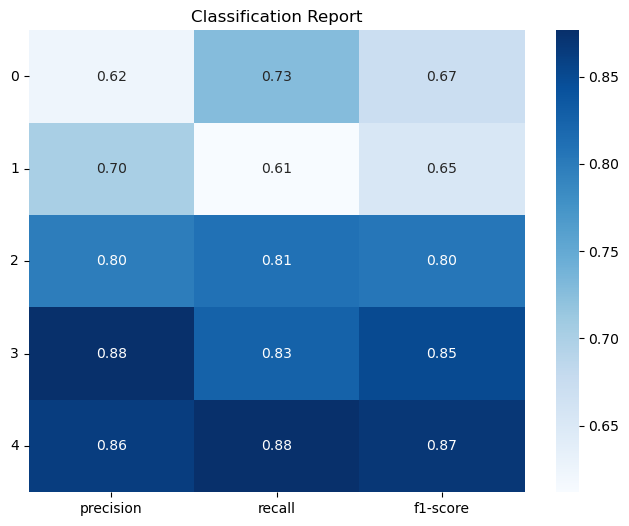

In [74]:
# Classification report 
report = classification_report(
    y_test_5,
    y_pred_lr,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,6))

sns.heatmap(
    report_df.iloc[:-3, :-1],  # only classes
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.yticks(rotation=0)
plt.title("Classification Report")
plt.show()

# 7. Model storage 

In [66]:
joblib.dump(
    {
        "model": lr_classifier,
        "label_encoder": le_5
    },
    "sentiment_analysis_tool.joblib"
)

['sentiment_analysis_tool.joblib']